# ch248 — Probability Distributions

**Part VIII: Probability** | Computational Mathematics for Programmers

---

## 1. What Is a Distribution?

A **probability distribution** is the complete specification of how probability is spread across the values of a random variable *(introduced in ch247)*. It answers: for any set of values, what is the probability X falls in that set?

There are two representations:
- **PMF** (probability mass function): for discrete RVs. p(x) = P(X = x).
- **PDF** (probability density function): for continuous RVs. f(x) such that P(a ≤ X ≤ b) = ∫ₐᵇ f(x) dx.

*(Integration was introduced in ch221 — Integration Intuition and ch223 — Numerical Integration.)*

---

## 2. The PDF and Why P(X = x) = 0 for Continuous RVs

For a continuous RV:
$$P(X = x) = \int_x^x f(t)\, dt = 0$$

The probability of any single point is zero. Probability lives in intervals, not points. This is not a bug — it is the nature of uncountably infinite sample spaces.

The PDF f(x) must satisfy:
1. f(x) ≥ 0 for all x
2. ∫₋∞^∞ f(x) dx = 1

Note: f(x) can exceed 1 (it's a density, not a probability). What must be ≤ 1 is any integral of f.

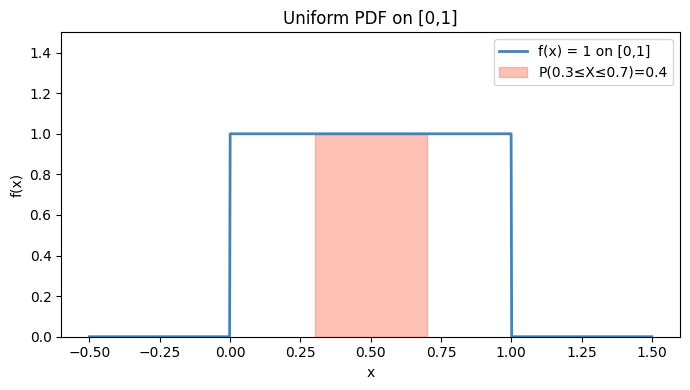

Total area under f (should be 1): 1.0010
P(0.3 <= X <= 0.7) = 0.3984


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Uniform distribution on [0,1]: f(x) = 1 for x in [0,1], else 0
x = np.linspace(-0.5, 1.5, 1000)
f_uniform = np.where((x >= 0) & (x <= 1), 1.0, 0.0)

# P(0.3 <= X <= 0.7) = integral from 0.3 to 0.7 of f(x) dx = 0.4
mask = (x >= 0.3) & (x <= 0.7)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x, f_uniform, 'steelblue', linewidth=2, label='f(x) = 1 on [0,1]')
ax.fill_between(x, 0, f_uniform, where=mask, alpha=0.4, color='tomato', label='P(0.3≤X≤0.7)=0.4')
ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.set_title('Uniform PDF on [0,1]')
ax.legend()
ax.set_ylim(0, 1.5)
plt.tight_layout()
plt.show()

# Numerical integration
dx = x[1] - x[0]
total_area = np.trapezoid(f_uniform, x)
shaded_area = np.trapezoid(f_uniform[mask], x[mask])
print(f"Total area under f (should be 1): {total_area:.4f}")
print(f"P(0.3 <= X <= 0.7) = {shaded_area:.4f}")

## 3. The Cumulative Distribution Function (CDF)

The **CDF** unifies discrete and continuous distributions:
$$F(x) = P(X \leq x)$$

For discrete RVs: F(x) = Σ_{t ≤ x} p(t)

For continuous RVs: F(x) = ∫₋∞^x f(t) dt

The CDF is always:
- Non-decreasing
- Right-continuous
- Bounded: F(−∞) = 0, F(+∞) = 1

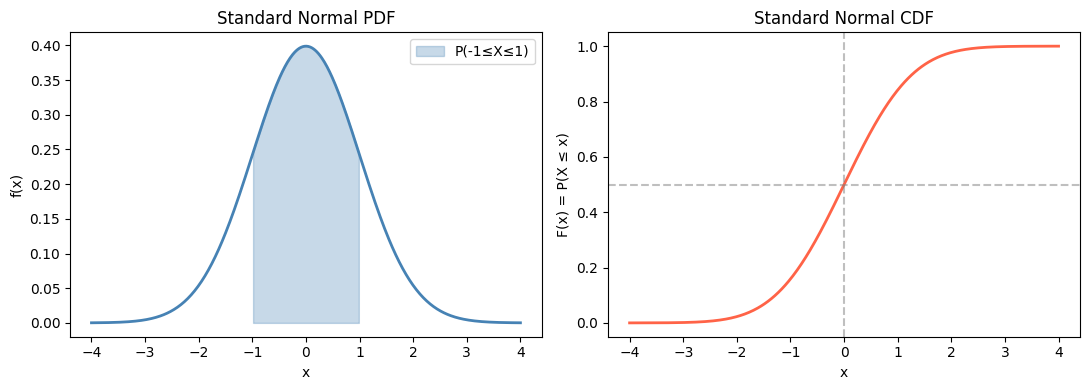

P(-1 <= X <= 1) = 0.6827  (~68%)
P(-2 <= X <= 2) = 0.9545  (~95%)
P(-3 <= X <= 3) = 0.9973  (~99.7%)


In [3]:
# Normal distribution: compare PDF and CDF
mu, sigma = 0, 1
rv = stats.norm(loc=mu, scale=sigma)

x = np.linspace(-4, 4, 500)
pdf_vals = rv.pdf(x)
cdf_vals = rv.cdf(x)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(x, pdf_vals, 'steelblue', linewidth=2)
axes[0].fill_between(x, 0, pdf_vals, where=(x >= -1) & (x <= 1),
                     alpha=0.3, color='steelblue', label='P(-1≤X≤1)')
axes[0].set_title('Standard Normal PDF')
axes[0].set_xlabel('x')
axes[0].set_ylabel('f(x)')
axes[0].legend()

axes[1].plot(x, cdf_vals, 'tomato', linewidth=2)
axes[1].axhline(0.5, color='gray', linestyle='--', alpha=0.5)
axes[1].axvline(0, color='gray', linestyle='--', alpha=0.5)
axes[1].set_title('Standard Normal CDF')
axes[1].set_xlabel('x')
axes[1].set_ylabel('F(x) = P(X ≤ x)')

plt.tight_layout()
plt.show()

print(f"P(-1 <= X <= 1) = {rv.cdf(1) - rv.cdf(-1):.4f}  (~68%)")
print(f"P(-2 <= X <= 2) = {rv.cdf(2) - rv.cdf(-2):.4f}  (~95%)")
print(f"P(-3 <= X <= 3) = {rv.cdf(3) - rv.cdf(-3):.4f}  (~99.7%)")

## 4. Parametric Families

Most useful distributions belong to parametric families — shapes determined by a small number of parameters. Parameters shift, scale, or reshape the distribution.

Key families:

| Distribution | Parameters | Support | Use |
|-------------|-----------|---------|-----|
| Uniform | a, b | [a,b] | Default uninformed prior |
| Bernoulli | p | {0,1} | Single binary trial |
| Binomial | n, p | {0,...,n} | Count successes in n trials |
| Poisson | λ | {0,1,2,...} | Count events in fixed interval |
| Exponential | λ | [0,∞) | Time between events |
| Normal | μ, σ² | ℝ | Sums of random quantities |
| Beta | α, β | [0,1] | Probabilities as random variables |

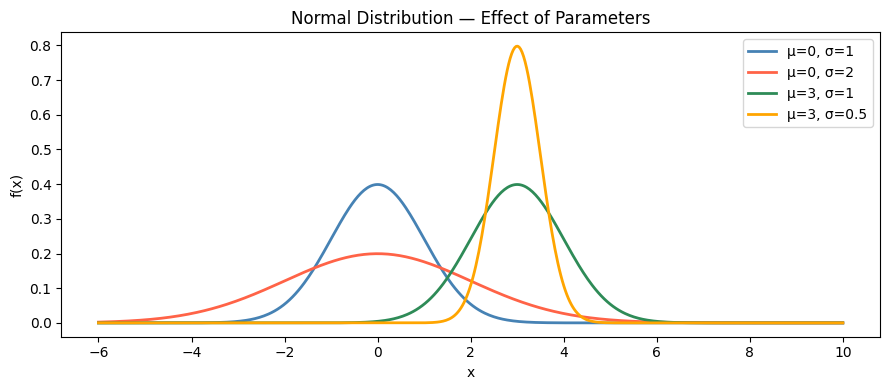

In [4]:
# Visualize how parameters shape the normal distribution
x = np.linspace(-6, 10, 500)

params = [
    {'mu': 0,  'sigma': 1,   'label': 'μ=0, σ=1',   'color': 'steelblue'},
    {'mu': 0,  'sigma': 2,   'label': 'μ=0, σ=2',   'color': 'tomato'},
    {'mu': 3,  'sigma': 1,   'label': 'μ=3, σ=1',   'color': 'seagreen'},
    {'mu': 3,  'sigma': 0.5, 'label': 'μ=3, σ=0.5', 'color': 'orange'},
]

fig, ax = plt.subplots(figsize=(9, 4))
for p in params:
    rv = stats.norm(loc=p['mu'], scale=p['sigma'])
    ax.plot(x, rv.pdf(x), color=p['color'], linewidth=2, label=p['label'])

ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.set_title('Normal Distribution — Effect of Parameters')
ax.legend()
plt.tight_layout()
plt.show()

## 5. Sampling from Distributions

The **inverse CDF method** generates samples from any distribution:
1. Draw u ~ Uniform(0, 1)
2. Return X = F⁻¹(u)

This works because if U is uniform, F⁻¹(U) has CDF F.

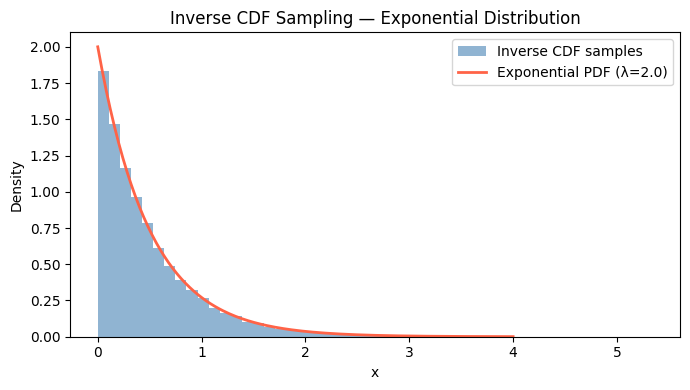

In [5]:
# Inverse CDF sampling for exponential distribution
# F(x) = 1 - exp(-lambda*x)  =>  F^-1(u) = -log(1-u)/lambda

lam = 2.0  # rate parameter
rng = np.random.default_rng(seed=42)
n = 10_000

# Our implementation
u = rng.uniform(0, 1, size=n)
samples_ours = -np.log(1 - u) / lam

# scipy reference
samples_scipy = stats.expon(scale=1/lam).rvs(n, random_state=0)

x_range = np.linspace(0, 4, 200)
pdf_exp = stats.expon(scale=1/lam).pdf(x_range)

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(samples_ours, bins=50, density=True, alpha=0.6, color='steelblue', label='Inverse CDF samples')
ax.plot(x_range, pdf_exp, 'tomato', linewidth=2, label=f'Exponential PDF (λ={lam})')
ax.set_xlabel('x')
ax.set_ylabel('Density')
ax.set_title('Inverse CDF Sampling — Exponential Distribution')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Summary

- A distribution specifies the complete probability structure of a random variable.
- Discrete RVs use PMFs (sums to 1); continuous RVs use PDFs (integrates to 1).
- The CDF F(x) = P(X ≤ x) works for both types and is the key tool for computing probabilities over intervals.
- Most useful distributions belong to parametric families whose shape is controlled by a small number of parameters.
- Sampling from any distribution can be done via the inverse CDF method.

---

## 7. Forward References

The specific distributions that appear everywhere in ML and statistics — binomial (ch251), Poisson (ch252), normal (ch253) — each build on the PMF/PDF framework introduced here. Expected value (ch249) and variance (ch250) summarize any distribution with two numbers. The relationship between distributions under scaling and addition is formalized by the Central Limit Theorem in ch254.